In [3]:
import os
import glob
import numpy as np
import warnings
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio import BiopythonWarning
from scipy.spatial.distance import cdist

warnings.simplefilter('ignore', BiopythonWarning)

CIF_DIR = "/share/home/wangtb/enzyme_shell/data/structure"

KEY_CATALYTIC_RESIDUES = {
    "1TT0": [(167, "HIS"), (548, "HIS"), (593, "ASN"), (448, "GLN"), (450, "HIS"), (546, "VAL"), (472, "ARG"), (454, "PHE"), (455, "SER"), (456, "TYR"), (457, "GLY"), (111, "LEU"), (545, "LEU"), (547, "LEU"), (101, "ASP"), (465, "SER"), (432, "GLU"), (451, "ARG"), (461, "GLN"), (99, "ASN"), (113, "SER"), (542, "GLU")],
    "5TOO": [(79, "THR"), (38, "ASP"), (305, "ASP"), (352, "ASP"), (309, "HIS"), (353, "HIS"), (486, "HIS"), (100, "ASN"), (162, "LYS"), (164, "ARG")],
    "PAFA": [(79, "THR"), (38, "ASP"), (305, "ASP"), (352, "ASP"), (309, "HIS"), (353, "HIS"), (486, "HIS"), (100, "ASN"), (162, "LYS"), (164, "ARG")],
    "1DDR": [(27, "ASP"), (100, "TYR"), (5, "ILE"), (31, "PHE"),(20, "MET")],
    "1BO7": [(198, "CYS"), (23, "ARG"), (178, "ARG"), (179, "ARG"), (218, "ARG"), (219, "SER"), (259, "HIS"), (261, "TYR"), (229, "ASN"), (221, "ASP"), (196, "PRO"), (197, "PRO")],
    "1RYA": [(124, "HIS"), (70, "GLU"), (37, "ARG"), (103, "TYR"), (22, "ASP"), (88, "HIS"), (90, "TYR"), (20, "SER"), (3, "PHE"), (9, "PHE"), (4, "LEU"), (52, "ARG"), (50, "GLY"), (123, "GLN")],
    "1KV8": [(11, "ASP"), (33, "GLU"), (62, "ASP"), (67, "ASP"), (136, "HIS"), (64, "LYS"), (192, "ARG"), (139, "ARG"), (36, "THR"), (169, "THR"), (171, "GLY"), (191, "GLY")],
    "1GSK": [(229, "CYS"), (322, "CYS"), (419, "HIS"), (492, "CYS"), (497, "HIS"), (502, "MET"), (103, "HIS"), (105, "HIS"), (151, "HIS"), (153, "HIS"), (422, "HIS"), (424, "HIS"), (491, "HIS"), (493, "HIS")],
    "1G99": [(384, "GLU"), (148, "ASP"), (91, "ARG"), (123, "HIS"), (180, "HIS"), (241, "ARG"), (93, "VAL"), (179, "PHE"), (228, "MET"), (232, "PRO"), (331, "GLY"), (7, "ASN"), (283, "ASP"), (284, "PHE"), (285, "ARG"), (208, "HIS"), (211, "ASN"), (212, "GLY"), (332, "ILE"), (339, "ILE")],
    "PTEN": [(124, "CYS"), (130, "ARG")]
}

def auto_detect_offset(chain, expected_residues, max_shift=200):
    cif_seq_dict = {}
    for res in chain:
        if res.id[0] == ' ':
            cif_seq_dict[res.id[1]] = res.get_resname().upper()
            
    best_offset = 0
    max_matches = -1
    
    # 在 -200 到 200 的范围内测试偏移量
    for offset in range(-max_shift, max_shift + 1):
        matches = 0
        for expected_id, expected_name in expected_residues:
            test_id = expected_id + offset
            if cif_seq_dict.get(test_id) == expected_name.upper():
                matches += 1
                
        # 记录匹配度最高的偏移量
        if matches > max_matches:
            max_matches = matches
            best_offset = offset
            
        # 如果全部完美匹配上了，直接跳出循环
        if max_matches == len(expected_residues):
            break
            
    return best_offset, max_matches

def calculate_heavy_atom_distance(chain, active_site_res, cif_name):
    """计算链中各残基与指定活性中心位点的最短重原子距离"""
    def get_heavy_atoms_coords(residue):
        coords = [atom.get_coord() for atom in residue if atom.element != 'H']
        return np.array(coords) if coords else np.array([])

    active_site_coords = []
    
    for res_id, expected_resname in active_site_res:
        try:
            target_res = chain[(' ', res_id, ' ')]
            actual_resname = target_res.resname.upper()
            
            if actual_resname != expected_resname.upper():
                print(f"  提示：序列变异！在 {cif_name} 位置 {res_id} 字典期望是 {expected_resname}，但结构中是 {actual_resname}。已采用当前残基计算。")
            
            res_coords = get_heavy_atoms_coords(target_res)
            active_site_coords.extend(res_coords)
            
        except KeyError:
            print(f"错误：在 {cif_name} 中未找到指定的残基位置 {res_id}。")
            return {} 
            
    active_site_coords = np.array(active_site_coords)
    if active_site_coords.size == 0:
        print(f"错误：{cif_name} 未能提取到任何催化中心重原子。")
        return {}
    
    distance_dict = {}
    for res in chain:
        if res.id[0] == ' ':  
            res_id = res.id[1]
            res_coords = get_heavy_atoms_coords(res)
            
            if res_coords.size > 0 and active_site_coords.size > 0:
                dist_matrix = cdist(res_coords, active_site_coords)
                min_dist = np.min(dist_matrix)
                distance_dict[res_id] = round(min_dist, 3)
                
    return distance_dict

def get_all_catalytic_distances():
    cif_files = glob.glob(os.path.join(CIF_DIR, "*.cif"))
    all_distances = {}
    parser = MMCIFParser(QUIET=True)
    
    if not cif_files:
        print(f"在 {CIF_DIR} 中未找到 CIF 文件。")
        return all_distances

    for cif_path in cif_files:
        filename = os.path.basename(cif_path)
        pdb_id = filename.replace('.cif', '').upper()
        
        if pdb_id not in KEY_CATALYTIC_RESIDUES:
            continue
            
        original_res_list = KEY_CATALYTIC_RESIDUES[pdb_id]
        
        try:
            structure = parser.get_structure('Target', cif_path)
            chain = structure[0]['A']
        except Exception as e:
            print(f"解析 {cif_path} 失败: {e}")
            continue

        # 核心修复：自动探测并应用偏移量
        offset, matches = auto_detect_offset(chain, original_res_list)
        total_expected = len(original_res_list)
        
        if offset != 0:
            print(f"[{pdb_id}] 检测到编号错位，已自动应用偏移量: {offset} (成功匹配残基: {matches}/{total_expected})")
        elif matches < total_expected:
            print(f"[{pdb_id}] 警告：未检测到错位偏移，但部分残基无法完美匹配 ({matches}/{total_expected})")

        mapped_res_list = [(res_id + offset, res_name) for res_id, res_name in original_res_list]
        
        dist_dict = calculate_heavy_atom_distance(chain, mapped_res_list, filename)
        
        if dist_dict:
            all_distances[pdb_id] = dist_dict
            
    print("\n批量计算完成！已返回嵌套字典。")
    return all_distances

distances_dict = get_all_catalytic_distances()
# 打印字典都含有哪些PDB ID
print("包含以下 PDB ID 的距离数据：")
for pdb_id in distances_dict.keys():
    print(f"  - {pdb_id}")
    

[1RYA] 检测到编号错位，已自动应用偏移量: -1 (成功匹配残基: 14/14)

批量计算完成！已返回嵌套字典。
包含以下 PDB ID 的距离数据：
  - PTEN
  - PAFA
  - 1BO7
  - 5TOO
  - 1RYA
  - 1TT0
  - 1KV8
  - 1GSK
  - 1G99
  - 1DDR


In [11]:
import os
import glob
import numpy as np
import torch
import re
import warnings
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio.PDB.Polypeptide import protein_letters_3to1
from Bio.Align import PairwiseAligner
from Bio import BiopythonWarning

warnings.simplefilter('ignore', BiopythonWarning)

AF_DIR = "/share/home/wangtb/enzyme_shell/data/structure"
DCA_BASE = "/share/home/wangtb/enzyme_shell/data/dca_result"
MPNN_BASE = "/share/home/wangtb/enzyme_shell/data/mpnn_result"

PROTEIN_IDS = ["1BO7", "1DDR", "1G99", "1GSK", "1KV8", "1RYA", "1TT0", "5TOO", "PAFA", "PTEN"]

def calc_metrics_from_muts(mut_dict, target_aa):
    if not mut_dict:
        return np.nan, np.nan

    all_scores = np.array(list(mut_dict.values()))
    probs = np.exp(-all_scores)
    Z = np.sum(probs) + 1e-10
    
    # Entropy 计算
    norm_probs = probs / Z
    entropy = -np.sum(norm_probs * np.log(norm_probs + 1e-10)) 
    
    # LogP 计算
    target_score = mut_dict.get(target_aa, 0.0)
    logp = np.log(np.exp(-target_score) / Z)
    
    return float(logp), float(entropy)

def get_pdb_sequence(cif_path, chain_id):
    parser = MMCIFParser(QUIET=True)
    try:
        struct = parser.get_structure("x", cif_path)
        chain = struct[0][chain_id]
    except Exception:
        return [], "", {}

    pdb_dict = {}
    seq = []
    res_ids = []

    for res in chain:
        if res.id[0] == ' ':
            resname = res.get_resname()
            if resname in protein_letters_3to1:
                rid = int(res.id[1])
                aa = protein_letters_3to1[resname]
                pdb_dict[rid] = aa
                seq.append(aa)
                res_ids.append(rid)

    return res_ids, "".join(seq), pdb_dict

def align_sequence(source_seq, target_pdb_seq, target_pdb_ids, source_indices, source_name=""):
    """使用局部动态规划比对，自动处理缺失、多余和错位片段，返回绝对映射关系"""
    aligner = PairwiseAligner()
    aligner.mode = "local"
    aligner.match_score = 2
    aligner.mismatch_score = -1
    aligner.open_gap_score = -5
    aligner.extend_gap_score = -1
    
    alns = aligner.align(source_seq, target_pdb_seq)
    if not alns:
        return {}
        
    aln = alns[0]
    mapping = {}
    
    # 解析比对路径，将源序列绝对索引与靶点序列绝对索引绑定
    for (src_start, src_end), (tgt_start, tgt_end) in zip(aln.aligned[0], aln.aligned[1]):
        for i in range(tgt_end - tgt_start):
            mapping[target_pdb_ids[tgt_start + i]] = source_indices[src_start + i]

    return mapping

def parse_dca(fasta_path):
    dca_data = {}
    with open(fasta_path, "r") as f:
        for line in f:
            if line.startswith(">"):
                words = line.strip()[1:].split("|")
                match = re.search(r'([a-zA-Z])\s*(\d+)\s*([a-zA-Z\-])', words[0])
                if match:
                    wt_aa = match.group(1).upper()
                    idx = int(match.group(2))
                    mut_aa = match.group(3).upper()
                    try:
                        score = float(words[1].split()[-1])
                    except ValueError:
                        continue
                    
                    if idx not in dca_data:
                        dca_data[idx] = {'wt': wt_aa, 'muts': {wt_aa: 0.0}}
                    if mut_aa != "-" and mut_aa != wt_aa:
                        dca_data[idx]['muts'][mut_aa] = score

    if not dca_data:
        return "", {}, []

    sorted_indices = sorted(list(dca_data.keys()))
    dca_seq = "".join([dca_data[i]['wt'] for i in sorted_indices])
            
    return dca_seq, dca_data, sorted_indices

def parse_mpnn(pt_path, target_chain_id):
    data = torch.load(pt_path, map_location='cpu')
    mpnn_data = {}
    
    local_idx = 0
    global_idx = 0
    
    valid_chains = set()
    for pos_key in data["mean_of_probs"]:
        match = re.match(r'^([a-zA-Z0-9_-]+?)(\d+)$', pos_key)
        if match: valid_chains.add(match.group(1))
        
    sorted_chains = sorted(list(valid_chains), key=len, reverse=True)

    for pos_key in data["mean_of_probs"]:
        matched_chain = "Unknown"
        for v_chain in sorted_chains:
            if pos_key.startswith(v_chain):
                if pos_key[len(v_chain):].isdigit():
                    matched_chain = v_chain
                    break
                    
        if matched_chain == target_chain_id:
            wt_alphabet_idx = data["native_sequence"][global_idx]
            wt = data["alphabet"][wt_alphabet_idx]
            
            mpnn_data[local_idx] = {'wt': wt, 'muts': {wt: 0.0}}

            probs_dict = data["mean_of_probs"][pos_key]
            wt_p = probs_dict.get(wt, 0.0)

            for mut, mut_p in probs_dict.items():
                if wt_p > 0 and mut_p > 0 and mut != wt:
                    mpnn_data[local_idx]['muts'][mut] = float(np.log(wt_p) - np.log(mut_p))

            local_idx += 1
        global_idx += 1

    sorted_indices = sorted(list(mpnn_data.keys()))
    seq_chars = "".join([mpnn_data[i]['wt'] for i in sorted_indices])
    return seq_chars, mpnn_data, sorted_indices

all_proteins_data = {}

print("开始批量提取模型得分、序列对齐校验并合并数据...\n")

for pid in PROTEIN_IDS:
    print(f"正在处理: {pid} ...")
    
    af_distance = distances_dict.get(pid, {}) if 'distances_dict' in globals() else {}
    
    cif_path = os.path.join(AF_DIR, f"{pid}.cif")
    res_ids, pdb_seq, pdb_dict = get_pdb_sequence(cif_path, "A")
    
    if not res_ids:
        print(f"  跳过: 未能从 {pid} 的 A 链提取到结构序列。")
        continue

    # DCA 数据获取
    dca_path = os.path.join(DCA_BASE, f"{pid}_DMS.fasta")
    dca_seq, dca_data, dca_indices = ("", {}, [])
    if os.path.exists(dca_path):
        dca_seq, dca_data, dca_indices = parse_dca(dca_path)
    else:
        print(f"  警告: 未找到 {pid} 的 DCA 结果")

    # MPNN 数据获取
    mpnn_path = os.path.join(MPNN_BASE, f"{pid}.pt")
    mpnn_seq, mpnn_data, mpnn_indices = ("", {}, [])
    if os.path.exists(mpnn_path):
        mpnn_seq, mpnn_data, mpnn_indices = parse_mpnn(mpnn_path, "A")
    else:
        print(f"  警告: 未找到 {pid} 的 MPNN 结果")

    # 基于 Local Aligner 建立 PDB 结构与模型的映射关系
    dca_map = align_sequence(dca_seq, pdb_seq, res_ids, dca_indices, source_name="DCA") if dca_seq else {}
    mpnn_map = align_sequence(mpnn_seq, pdb_seq, res_ids, mpnn_indices, source_name="MPNN") if mpnn_seq else {}

    dca_logp_dict, dca_entropy_dict, dca_score_dict = {}, {}, {}
    mpnn_logp_dict, mpnn_entropy_dict, mpnn_score_dict = {}, {}, {}
    
    # 🆕 新增：用于存储包含 20 种氨基酸的完整突变打分字典
    dca_all_muts_dict = {}
    mpnn_all_muts_dict = {}
    
    validation_mapping = {} # 用于校验氨基酸匹配的字典

    # 统计数据
    mapped_count = 0
    dca_mismatch = 0
    mpnn_mismatch = 0

    for rid, pdb_aa in pdb_dict.items():
        val_entry = {"pdb_aa": pdb_aa, "dca_wt": None, "mpnn_wt": None}
        is_mapped = False

        if rid in dca_map:
            d_idx = dca_map[rid]
            if d_idx in dca_data:
                is_mapped = True
                dca_wt = dca_data[d_idx]['wt']
                val_entry["dca_wt"] = dca_wt
                
                # 校验：检查结构氨基酸是否与DCA预测输入的野生型一致
                if pdb_aa != dca_wt:
                    dca_mismatch += 1
                
                muts_dict = dca_data[d_idx]['muts']
                logp, ent = calc_metrics_from_muts(muts_dict, target_aa=pdb_aa)
                
                dca_logp_dict[rid] = logp
                dca_entropy_dict[rid] = ent
                dca_score_dict[rid] = muts_dict.get(pdb_aa, 0.0) 
                dca_all_muts_dict[rid] = muts_dict # 🆕 存储完整的 DCA 突变打分
                
        if rid in mpnn_map:
            m_idx = mpnn_map[rid]
            if m_idx in mpnn_data:
                is_mapped = True
                mpnn_wt = mpnn_data[m_idx]['wt']
                val_entry["mpnn_wt"] = mpnn_wt
                
                # 校验：检查结构氨基酸是否与MPNN预测输入的野生型一致
                if pdb_aa != mpnn_wt:
                    mpnn_mismatch += 1

                muts_dict = mpnn_data[m_idx]['muts']
                logp, ent = calc_metrics_from_muts(muts_dict, target_aa=pdb_aa)
                
                mpnn_logp_dict[rid] = logp
                mpnn_entropy_dict[rid] = ent
                mpnn_score_dict[rid] = muts_dict.get(pdb_aa, 0.0) 
                mpnn_all_muts_dict[rid] = muts_dict # 🆕 存储完整的 MPNN 突变打分
        
        if is_mapped:
            mapped_count += 1
            validation_mapping[rid] = val_entry

    # 输出校验总结
    print(f"    - 成功映射残基: {mapped_count} / {len(pdb_dict)}")
    if dca_mismatch > 0:
        print(f"    - DCA序列冲突: 发现 {dca_mismatch} 处 PDB序列 与 DCA输入野生型 不一致！(已自适应取对应氨基酸分数)")
    if mpnn_mismatch > 0:
        print(f"    - MPNN序列冲突: 发现 {mpnn_mismatch} 处 PDB序列 与 MPNN输入野生型 不一致！(已自适应取对应氨基酸分数)")

    all_proteins_data[pid] = {
        "af_distance": af_distance,      
        "dca_logp": dca_logp_dict,            
        "dca_entropy": dca_entropy_dict,
        "dca_score": dca_score_dict,          
        "dca_all_muts": dca_all_muts_dict,
        "mpnn_logp": mpnn_logp_dict,          
        "mpnn_entropy": mpnn_entropy_dict,
        "mpnn_score": mpnn_score_dict,        
        "mpnn_all_muts": mpnn_all_muts_dict,
        "validation_mapping": validation_mapping
    }

print("\n处理完成！最终数据及校验报告已整合到 all_proteins_data 字典中。")

开始批量提取模型得分、序列对齐校验并合并数据...

正在处理: 1BO7 ...
    - 成功映射残基: 316 / 316
正在处理: 1DDR ...
    - 成功映射残基: 159 / 159
正在处理: 1G99 ...
    - 成功映射残基: 408 / 408
正在处理: 1GSK ...
    - 成功映射残基: 509 / 509
    - DCA序列冲突: 发现 14 处 PDB序列 与 DCA输入野生型 不一致！(已自适应取对应氨基酸分数)
正在处理: 1KV8 ...
    - 成功映射残基: 216 / 216
正在处理: 1RYA ...
    - 成功映射残基: 159 / 159
正在处理: 1TT0 ...
    - 成功映射残基: 623 / 623
正在处理: 5TOO ...
    - 成功映射残基: 546 / 546
正在处理: PAFA ...
    - 成功映射残基: 546 / 546
正在处理: PTEN ...
    - 成功映射残基: 307 / 307

处理完成！最终数据及校验报告已整合到 all_proteins_data 字典中。


In [12]:
conflict_records = all_proteins_data['1GSK']['validation_mapping']

print("1GSK 序列不一致位点明细：")
for rid, info in conflict_records.items():
    if info['pdb_aa'] != info['dca_wt']:
        print(f"PDB 残基编号: {rid} | 结构中是: {info['pdb_aa']} | DCA以为是: {info['dca_wt']} | 我们最终取了: {info['pdb_aa']}")

1GSK 序列不一致位点明细：
PDB 残基编号: 41 | 结构中是: R | DCA以为是: S | 我们最终取了: R
PDB 残基编号: 54 | 结构中是: S | DCA以为是: G | 我们最终取了: S
PDB 残基编号: 61 | 结构中是: H | DCA以为是: K | 我们最终取了: H
PDB 残基编号: 90 | 结构中是: E | DCA以为是: A | 我们最终取了: E
PDB 残基编号: 293 | 结构中是: T | DCA以为是: S | 我们最终取了: T
PDB 残基编号: 312 | 结构中是: K | DCA以为是: Q | 我们最终取了: K
PDB 残基编号: 315 | 结构中是: T | DCA以为是: V | 我们最终取了: T
PDB 残基编号: 348 | 结构中是: P | DCA以为是: A | 我们最终取了: P
PDB 残基编号: 368 | 结构中是: Q | DCA以为是: N | 我们最终取了: Q
PDB 残基编号: 391 | 结构中是: H | DCA以为是: Q | 我们最终取了: H
PDB 残基编号: 410 | 结构中是: S | DCA以为是: N | 我们最终取了: S
PDB 残基编号: 439 | 结构中是: E | DCA以为是: D | 我们最终取了: E
PDB 残基编号: 440 | 结构中是: V | DCA以为是: I | 我们最终取了: V
PDB 残基编号: 446 | 结构中是: D | DCA以为是: E | 我们最终取了: D


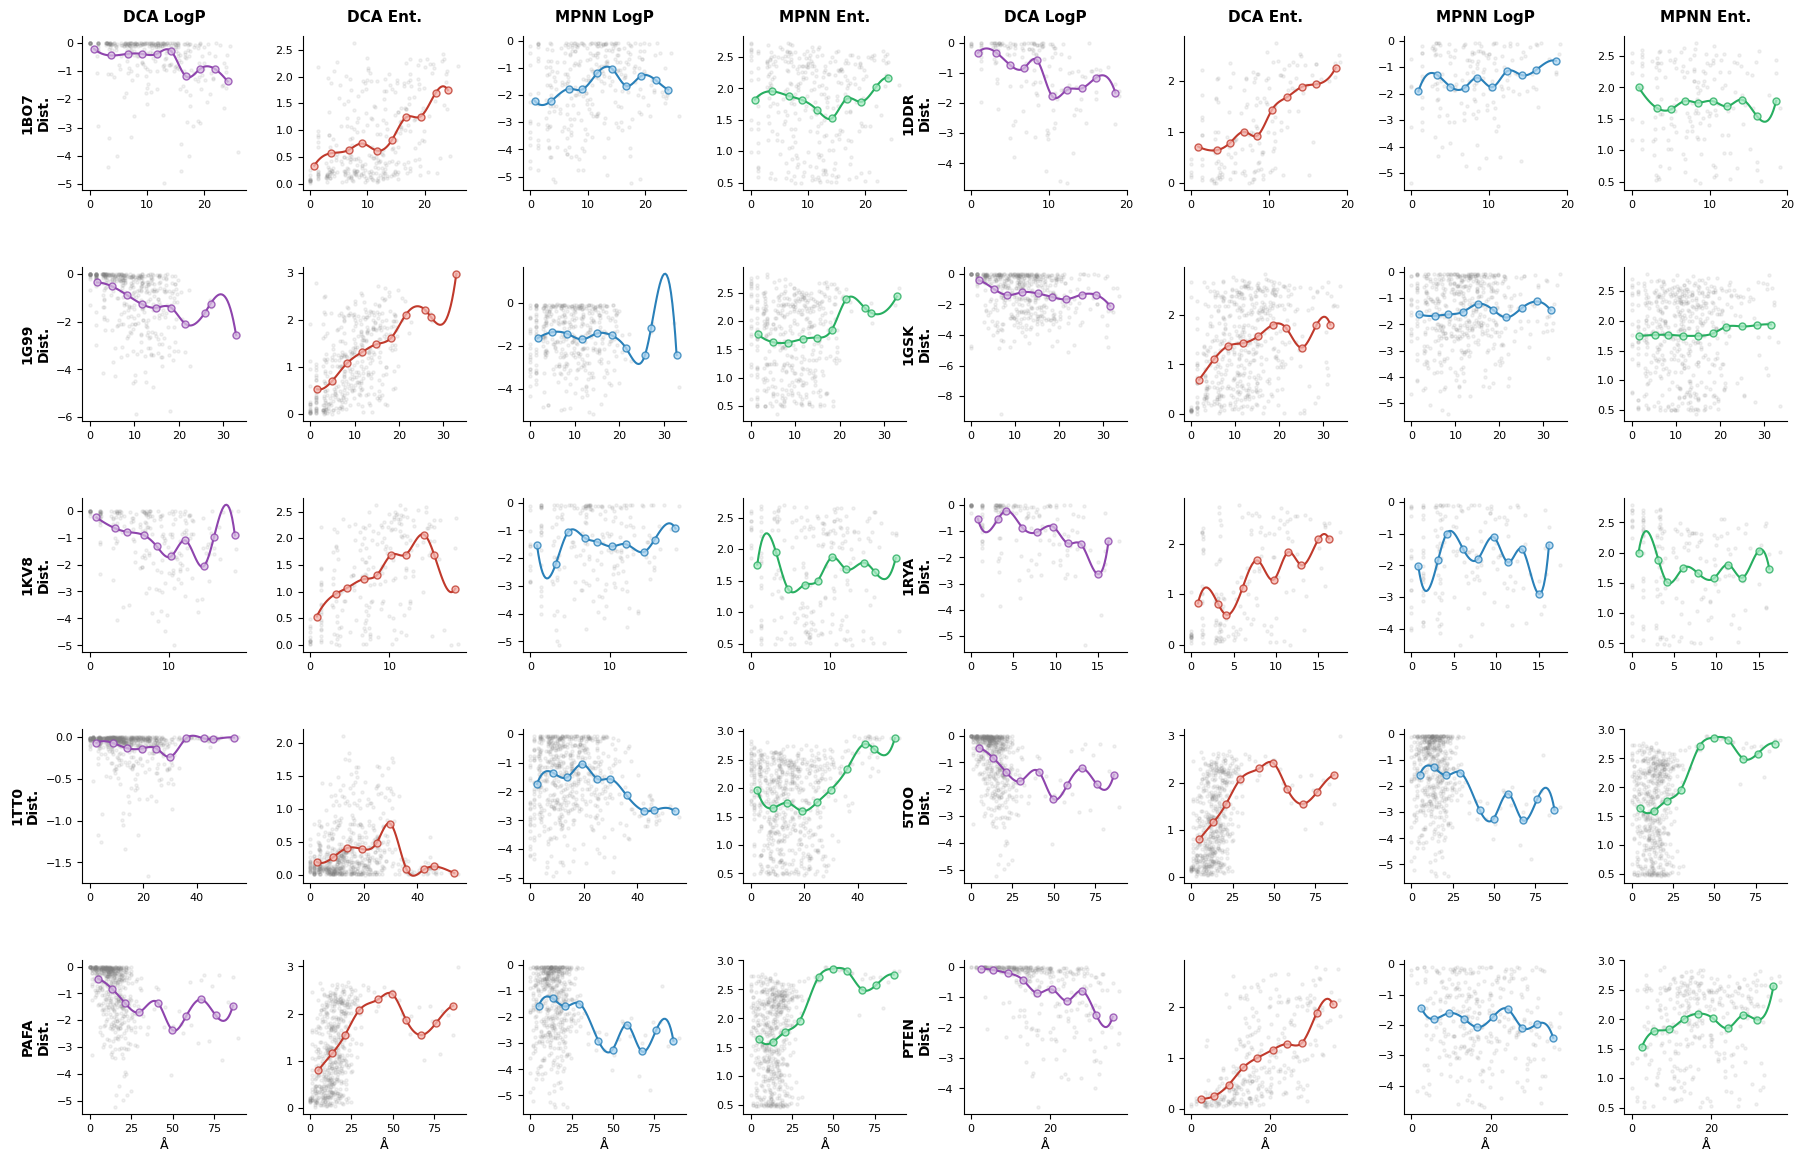

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

def plot_proteins_5x2_grid(all_proteins_data, default_bins=10):
    # 定义指标和标题
    metrics = ["dca_logp", "dca_entropy", "mpnn_logp", "mpnn_entropy"]
    short_titles = ["DCA LogP", "DCA Ent.", "MPNN LogP", "MPNN Ent."]
    
    # 颜色配置
    colors = [
        ('#8E44AD', '#D7BDE2'), # DCA LogP - 紫
        ('#C0392B', '#F5B7B1'), # DCA Entropy - 红
        ('#2980B9', '#AED6F1'), # MPNN LogP - 蓝
        ('#27AE60', '#ABEBC6')  # MPNN Entropy - 绿
    ]
    
    protein_ids = list(all_proteins_data.keys())
    # 确保只处理前10个，或者根据实际数量调整
    n_proteins = len(protein_ids)
    
    # 创建 5行 x 8列 的画布
    # 每列宽度约 3 英寸，总宽 22 英寸，总高 15 英寸
    fig, axes = plt.subplots(5, 8, figsize=(22, 14))
    
    for i, pid in enumerate(protein_ids):
        if i >= 10: break # 只处理前10个
        
        # 计算当前蛋白在 5x2 蛋白网格中的位置
        row = i // 2
        col_offset = (i % 2) * 4 # 左边蛋白占 0-3 列，右边蛋白占 4-7 列
        
        feats = all_proteins_data[pid]
        distances = feats.get("af_distance", {})
        
        # 准备数据
        data_list = []
        for pos, dist in distances.items():
            entry = {"dist": dist}
            for m in metrics:
                entry[m] = feats.get(m, {}).get(pos, np.nan)
            data_list.append(entry)
        df = pd.DataFrame(data_list)

        # 依次绘制该蛋白的 4 个指标
        for m_idx, m_col in enumerate(metrics):
            ax = axes[row, col_offset + m_idx]
            line_c, scatter_c = colors[m_idx]
            
            curr_df = df.dropna(subset=["dist", m_col]).copy()
            
            if curr_df.empty:
                ax.text(0.5, 0.5, "N/A", transform=ax.transAxes, ha='center', color='gray')
            else:
                # 分箱处理
                n_bins = min(default_bins, max(4, len(curr_df) // 15))
                curr_df['bin'] = pd.cut(curr_df["dist"], bins=n_bins, labels=False)
                grouped = curr_df.groupby('bin', observed=True).mean(numeric_only=True).reset_index()
                
                x_raw, y_raw = curr_df["dist"].values, curr_df[m_col].values
                x_bin, y_bin = grouped["dist"].values, grouped[m_col].values

                # 绘制背景散点
                ax.scatter(x_raw, y_raw, alpha=0.1, s=5, color='gray', zorder=1)
                
                # 绘制分箱点
                ax.scatter(x_bin, y_bin, s=25, color=scatter_c, edgecolor=line_c, alpha=0.8, zorder=3)
                
                # 绘制平滑趋势线
                if len(x_bin) > 3:
                    try:
                        x_smooth = np.linspace(x_bin.min(), x_bin.max(), 100)
                        spline = make_interp_spline(np.sort(x_bin), y_bin[np.argsort(x_bin)], k=3)
                        ax.plot(x_smooth, spline(x_smooth), color=line_c, linewidth=1.5, zorder=2)
                    except:
                        ax.plot(np.sort(x_bin), y_bin[np.argsort(x_bin)], color=line_c, linewidth=1.5, zorder=2)


            if row == 0:
                ax.set_title(short_titles[m_idx], fontsize=11, fontweight='bold', pad=10)
            
            if m_idx == 0:
                ax.set_ylabel(f"{pid}\nDist.", fontsize=10, fontweight='bold')
            else:
                ax.set_ylabel("")

            if row == 4:
                ax.set_xlabel("Å", fontsize=9)
            
            ax.tick_params(axis='both', which='major', labelsize=8)
            sns.despine(ax=ax)

    plt.subplots_adjust(wspace=0.35, hspace=0.5)

    plt.show()

# 调用绘图
plot_proteins_5x2_grid(all_proteins_data)

In [15]:
import os
import glob
import pandas as pd
import re
import numpy as np

# 路径配置
CSV_DIR = "/share/home/wangtb/enzyme_shell/data/activity"

csv_files = glob.glob(os.path.join(CSV_DIR, "*.csv"))

print("开始批量校验突变位点并更新得分及距离 (直接覆盖原文件)...\n")

for csv_file in csv_files:
    filename = os.path.basename(csv_file)

    # 提取蛋白 ID (兼容 1_1DDR.csv 或其他格式)
    match = re.search(r'([A-Z0-9]{4})', filename.upper())
    if not match:
        print(f"跳过无法识别 ID 的文件: {filename}")
        continue

    pid = match.group(1)

    # PAFA 和 PTEN 特殊处理
    if "PAFA" in filename.upper():
        pid = "PAFA"
    if "PTEN" in filename.upper():
        pid = "PTEN"

    if pid not in all_proteins_data:
        print(f"字典中无 {pid} 的数据，跳过 {filename}")
        continue

    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"读取 {filename} 失败: {e}")
        continue

    # 自动识别突变列名
    mut_col = None
    if 'mutant' in df.columns:
        mut_col = 'mutant'
    elif 'Variant (one letter)' in df.columns:
        mut_col = 'Variant (one letter)'

    if not mut_col:
        print(f"{filename} 中未找到 mutant 或 Variant 列，跳过")
        continue

    prot_data = all_proteins_data[pid]

    updated_dca = []
    updated_mpnn = []
    updated_distance = []

    match_count = 0
    mismatch_count = 0

    for idx, row in df.iterrows():
        mut_str = str(row[mut_col])

        if pd.isna(mut_str) or mut_str.strip() == '':
            updated_dca.append(np.nan)
            updated_mpnn.append(np.nan)
            updated_distance.append(np.nan)
            continue

        # 按 '/' 拆分多点突变 (如 H45R/W47Y/I50F)
        mutations = mut_str.split('/')
        row_dca_scores = []
        row_mpnn_scores = []
        row_distances = []

        for m in mutations:
            m = m.strip()

            # 解析例如 "I155T" -> wt='I', pos=155, mut='T'
            parsed = re.match(r'([a-zA-Z])(\d+)([a-zA-Z])', m)

            if parsed:
                csv_wt = parsed.group(1).upper()
                pos = int(parsed.group(2))
                mut_aa = parsed.group(3).upper()

                # 获取结构距离
                dist = prot_data.get('af_distance', {}).get(pos, np.nan)

                # 核心检验：CSV里的野生型 vs 真实结构字典里的野生型
                val_info = prot_data['validation_mapping'].get(pos)

                if val_info and val_info['pdb_aa'] == csv_wt:
                    # 匹配成功！查阅突变体的具体得分
                    d_score = prot_data['dca_all_muts'].get(pos, {}).get(mut_aa, np.nan)
                    m_score = prot_data['mpnn_all_muts'].get(pos, {}).get(mut_aa, np.nan)
                    match_count += 1
                else:
                    # 不匹配或结构中缺失该残基
                    d_score, m_score = np.nan, np.nan
                    mismatch_count += 1

                row_dca_scores.append(str(round(d_score, 4)) if pd.notna(d_score) else "NaN")
                row_mpnn_scores.append(str(round(m_score, 4)) if pd.notna(m_score) else "NaN")
                row_distances.append(str(round(dist, 3)) if pd.notna(dist) else "NaN")
            else:
                row_dca_scores.append("NaN")
                row_mpnn_scores.append("NaN")
                row_distances.append("NaN")

        # 重新用 '/' 拼接多点突变的得分和距离
        updated_dca.append("/".join(row_dca_scores))
        updated_mpnn.append("/".join(row_mpnn_scores))
        updated_distance.append("/".join(row_distances))

    # 直接覆盖原始列
    df['DCA_score'] = updated_dca
    df['LigandMPNN_score'] = updated_mpnn
    df['Distance_to_Active_Site'] = updated_distance

    # 直接在原文件写入
    df.to_csv(csv_file, index=False)

    print(f"{pid} ({filename}) 处理完毕并已覆盖原文件 | 成功匹配: {match_count} 处 | 冲突/缺失: {mismatch_count} 处")
    print("-" * 40)

print("所有 CSV 文件已在原目录更新完毕！")

开始批量校验突变位点并更新得分及距离 (直接覆盖原文件)...

PAFA (3_PAFA.csv) 处理完毕并已覆盖原文件 | 成功匹配: 1018 处 | 冲突/缺失: 0 处
----------------------------------------
PTEN (3_PTEN.csv) 处理完毕并已覆盖原文件 | 成功匹配: 5060 处 | 冲突/缺失: 0 处
----------------------------------------
1DDR (1_1DDR.csv) 处理完毕并已覆盖原文件 | 成功匹配: 58 处 | 冲突/缺失: 0 处
----------------------------------------
1GSK (1_1GSK.csv) 处理完毕并已覆盖原文件 | 成功匹配: 52 处 | 冲突/缺失: 0 处
----------------------------------------
1TT0 (1_1TT0.csv) 处理完毕并已覆盖原文件 | 成功匹配: 36 处 | 冲突/缺失: 0 处
----------------------------------------
1BO7 (2_1BO7.csv) 处理完毕并已覆盖原文件 | 成功匹配: 44 处 | 冲突/缺失: 0 处
----------------------------------------
1G99 (2_1G99.csv) 处理完毕并已覆盖原文件 | 成功匹配: 21 处 | 冲突/缺失: 0 处
----------------------------------------
1RYA (3_1RYA.csv) 处理完毕并已覆盖原文件 | 成功匹配: 27 处 | 冲突/缺失: 0 处
----------------------------------------
5TOO (3_5TOO.csv) 处理完毕并已覆盖原文件 | 成功匹配: 105 处 | 冲突/缺失: 0 处
----------------------------------------
1KV8 (4_1KV8.csv) 处理完毕并已覆盖原文件 | 成功匹配: 39 处 | 冲突/缺失: 0 处
---------------------------------

In [1]:
import pandas as pd
import os
import glob

# ================= 配置路径 =================
base_activity_dir = "/share/home/wangtb/enzyme_shell/data/activity"
base_foldx_dir = "/share/home/wangtb/enzyme_shell/data/foldx_result/other_proteins"

target_proteins = [
    "1BO7", "1DDR", "1G99", "1GSK", 
    "1KV8", "1RYA", "1TT0", "5TOO"
]
# ============================================

print("开始解析 8 个蛋白的 FoldX 结果并回写到原始 CSV...\n")

for prot in target_proteins:
    # 1. 自动寻找对应的原始 CSV 文件 (例如 1_1DDR.csv)
    csv_files = glob.glob(os.path.join(base_activity_dir, f"*_{prot}.csv"))
    if not csv_files:
        print(f"警告: 找不到 {prot} 的原始 CSV 文件，跳过。")
        continue
    
    original_csv = csv_files[0]
    
    # 2. 定位该蛋白的拆分任务和结果文件夹
    split_lists_dir = os.path.join(base_foldx_dir, "split_lists", prot)
    results_dir = os.path.join(base_foldx_dir, "results_all", prot)
    
    mut_files = glob.glob(os.path.join(split_lists_dir, "mut_list_*.txt"))
    num_tasks = len(mut_files)
    
    if num_tasks == 0:
        print(f"警告: {prot} 目录下没有找到任务列表，跳过。")
        continue

    mutation_to_ddg = {}
    failed_tasks = []

    # 3. 逐个子任务精准解析
    for i in range(1, num_tasks + 1):
        mut_file = os.path.join(split_lists_dir, f"mut_list_{i}.txt")
        fxout_file = os.path.join(results_dir, f"Dif_result_{i}.fxout")

        if os.path.exists(mut_file) and os.path.exists(fxout_file):
            
            # 读取输入的突变
            with open(mut_file, 'r') as f:
                muts = [line.strip().strip(';') for line in f if line.strip()]

            # 过滤 FoldX 输出的数据行
            fx_lines = []
            with open(fxout_file, 'r') as f:
                for line in f:
                    line = line.strip()
                    parts = line.split('\t')
                    if len(parts) > 5 and parts[0].endswith('.pdb'):
                        fx_lines.append(parts)

            # 校验行数
            if len(muts) != len(fx_lines):
                print(f"  警告: {prot} 任务 {i} 突变数量({len(muts)})与有效结果行数({len(fx_lines)})不匹配，跳过。")
                failed_tasks.append(i)
                continue

            # 匹配并组装映射字典
            for mut_str, parts in zip(muts, fx_lines):
                # 兼容单突变和多突变：将 FoldX 的 RA36Q,YA102F 还原成 CSV 中的 R36Q/Y102F
                csv_variant_parts = []
                for sub_mut in mut_str.split(','):
                    wt = sub_mut[0]
                    mut = sub_mut[-1]
                    pos = sub_mut[2:-1] 
                    csv_variant_parts.append(f"{wt}{pos}{mut}")
                
                csv_variant = "/".join(csv_variant_parts)

                try:
                    ddg_score = float(parts[1])
                    mutation_to_ddg[csv_variant] = ddg_score
                except ValueError:
                    pass
        else:
            failed_tasks.append(i)

    if failed_tasks:
        print(f"  提示: {prot} 的以下任务未成功生成结果: {failed_tasks}")

    # 4. 映射回写并覆盖原 CSV
    df = pd.read_csv(original_csv)
    df['FoldX_ddG'] = df['mutant'].map(mutation_to_ddg)
    df.to_csv(original_csv, index=False)
    
    print(f"成功: {prot} 处理完成！提取了 {len(mutation_to_ddg)} 个突变分数，已成功覆写至原表。")

print("\n全部 8 个蛋白数据合并完毕！")

开始解析 8 个蛋白的 FoldX 结果并回写到原始 CSV...

成功: 1BO7 处理完成！提取了 44 个突变分数，已成功覆写至原表。
成功: 1DDR 处理完成！提取了 53 个突变分数，已成功覆写至原表。
成功: 1G99 处理完成！提取了 21 个突变分数，已成功覆写至原表。
成功: 1GSK 处理完成！提取了 22 个突变分数，已成功覆写至原表。
成功: 1KV8 处理完成！提取了 22 个突变分数，已成功覆写至原表。
成功: 1RYA 处理完成！提取了 22 个突变分数，已成功覆写至原表。
成功: 1TT0 处理完成！提取了 25 个突变分数，已成功覆写至原表。
成功: 5TOO 处理完成！提取了 105 个突变分数，已成功覆写至原表。

全部 8 个蛋白数据合并完毕！
